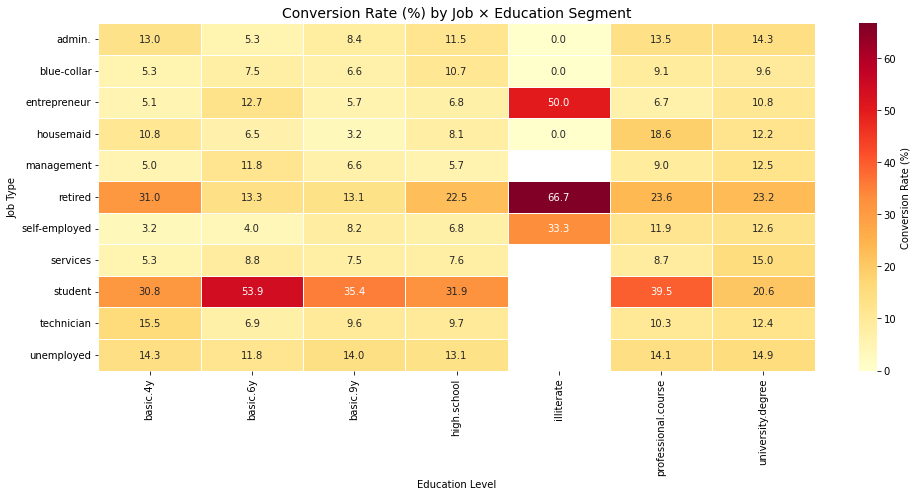

Heatmap saved.


In [2]:
# 03_segment_analysis.py

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bank_customers_clean.csv')
# Why: Shows which job+education combo has best conversion — feeds Excel P&L model

pivot = df.groupby(['job', 'education'])['subscribed'].mean().unstack() * 100
pivot = pivot.round(2)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Conversion Rate (%)'})
plt.title('Conversion Rate (%) by Job × Education Segment', fontsize=14)
plt.xlabel('Education Level')
plt.ylabel('Job Type')
plt.tight_layout()
plt.savefig('outputs/chart_05_job_education_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved.")


Previous outcome × Age band:
        poutcome  age_band  total  converted  conversion_rate
0       failure  Under 25    168         47            27.98
1       failure     25–34   1479        193            13.05
2       failure     35–44   1335        147            11.01
3       failure     45–54    785         93            11.85
4       failure     55–64    327         71            21.71
5       failure       65+    158         54            34.18
6   nonexistent  Under 25    803        142            17.68
7   nonexistent     25–34  11754       1188            10.11
8   nonexistent     35–44  11847        822             6.94
9   nonexistent     45–54   7707        533             6.92
10  nonexistent     55–64   3078        299             9.71
11  nonexistent       65+    374        157            41.98
12      success  Under 25     97         67            69.07
13      success     25–34    453        285            62.91
14      success     35–44    318        199           

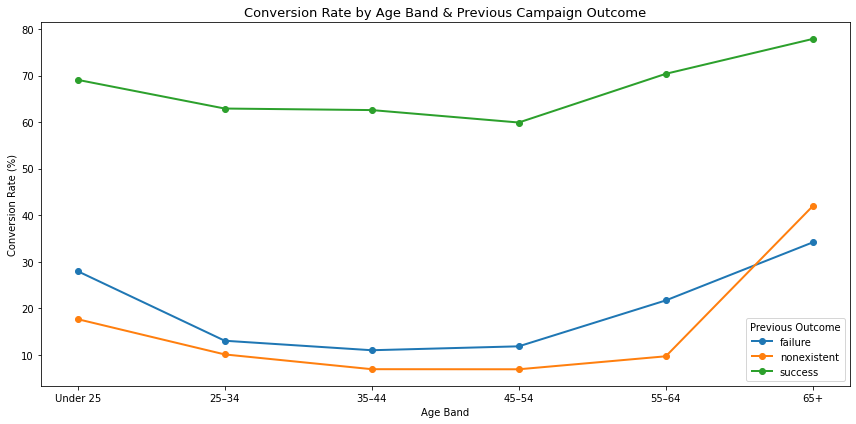

In [3]:
# ── Analysis 2: Previous outcome × Age band ─────────────────────────────────

bins = [0, 24, 34, 44, 54, 64, 100]
labels = ['Under 25', '25–34', '35–44', '45–54', '55–64', '65+']
df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels)

seg2 = df.groupby(['poutcome', 'age_band'], observed=True)['subscribed'].agg(
    total='count',
    converted='sum'
).reset_index()
seg2['conversion_rate'] = round(seg2['converted'] / seg2['total'] * 100, 2)

print("\nPrevious outcome × Age band:\n", seg2.to_string())

# Chart
plt.figure(figsize=(12, 6))
for outcome in seg2['poutcome'].dropna().unique():
    subset = seg2[seg2['poutcome'] == outcome]
    plt.plot(subset['age_band'].astype(str), subset['conversion_rate'],
             marker='o', label=outcome, linewidth=2)

plt.title('Conversion Rate by Age Band & Previous Campaign Outcome', fontsize=13)
plt.xlabel('Age Band')
plt.ylabel('Conversion Rate (%)')
plt.legend(title='Previous Outcome')
plt.tight_layout()
plt.savefig('outputs/chart_06_age_poutcome.png', dpi=150)
plt.show()

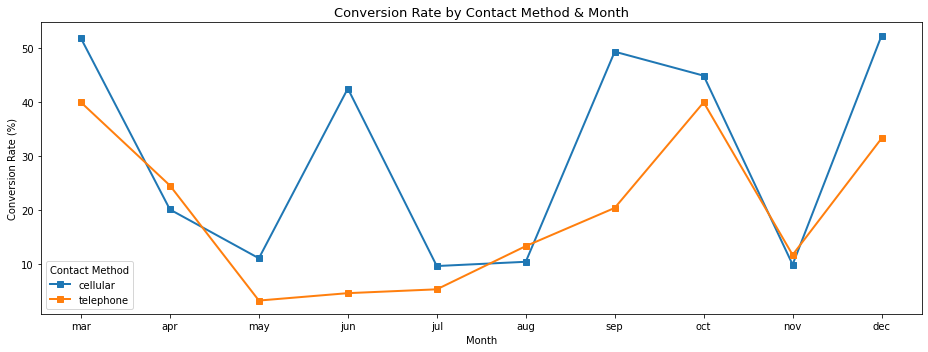

In [4]:
# ── Analysis 3: Contact method × Month efficiency ───────────────────────────
# Why: Operational efficiency — cellular vs telephone, and best months to call

contact_month = df.groupby(['contact', 'month'])['subscribed'].agg(
    total='count',
    converted='sum'
).reset_index()
contact_month['conversion_rate'] = round(
    contact_month['converted'] / contact_month['total'] * 100, 2
)

month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']
contact_month['month'] = pd.Categorical(
    contact_month['month'], categories=month_order, ordered=True
)
contact_month = contact_month.sort_values('month')

plt.figure(figsize=(13, 5))
for method in contact_month['contact'].unique():
    subset = contact_month[contact_month['contact'] == method]
    plt.plot(subset['month'].astype(str), subset['conversion_rate'],
             marker='s', label=method, linewidth=2)

plt.title('Conversion Rate by Contact Method & Month', fontsize=13)
plt.xlabel('Month')
plt.ylabel('Conversion Rate (%)')
plt.legend(title='Contact Method')
plt.tight_layout()
plt.savefig('outputs/chart_07_contact_month.png', dpi=150)
plt.show()

In [5]:
# ── Summary table: Top 10 segments ──────────────────────────────────────────

top_segments = df.groupby(['job', 'education', 'age_band'], observed=True).agg(
    total=('subscribed', 'count'),
    converted=('subscribed', 'sum')
).reset_index()

top_segments['conversion_rate'] = round(
    top_segments['converted'] / top_segments['total'] * 100, 2
)
top_segments = top_segments[top_segments['total'] >= 100]  # filter small samples
top_segments = top_segments.sort_values('conversion_rate', ascending=False).head(10)

print("\nTop 10 highest-converting segments:\n")
print(top_segments.to_string(index=False))

# Save for Excel model
top_segments.to_csv('outputs/top_segments.csv', index=False)
print("\nTop segments saved to outputs/top_segments.csv")


Top 10 highest-converting segments:

       job           education age_band  total  converted  conversion_rate
   retired            basic.4y      65+    261        133            50.96
   student         high.school Under 25    184         64            34.78
   student         high.school    25–34    166         49            29.52
   student   university.degree    25–34    125         26            20.80
   retired   university.degree    55–64    171         33            19.30
   retired         high.school    55–64    166         31            18.67
    admin.         high.school    55–64    177         33            18.64
    admin. professional.course    25–34    109         20            18.35
   retired professional.course    55–64    143         26            18.18
unemployed   university.degree    25–34    116         21            18.10

Top segments saved to outputs/top_segments.csv


In [6]:
# 0anomaly_detection.py
# To Detect statistical anomalies in campaign behavior and customer profiles


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('bank_customers_clean.csv')

# ── Anomaly 1: Customers called an unusually high number of times ────────────
# Why: Over-calling wastes budget and annoys customers. Flag the outliers.

z_scores = np.abs(stats.zscore(df['campaign'].dropna()))
df_z = df.dropna(subset=['campaign']).copy()
df_z['campaign_zscore'] = z_scores

threshold = 3.0
anomalies = df_z[df_z['campaign_zscore'] > threshold]

print(f"Total customers: {len(df):,}")
print(f"Customers called abnormally often (z > {threshold}): {len(anomalies):,}")
print(f"Max calls to one customer: {df['campaign'].max()}")
print(f"\nAnomaly summary:\n{anomalies['campaign'].describe()}")

Total customers: 41,188
Customers called abnormally often (z > 3.0): 869
Max calls to one customer: 56

Anomaly summary:
count    869.000000
mean      16.197929
std        6.080106
min       11.000000
25%       12.000000
50%       14.000000
75%       18.000000
max       56.000000
Name: campaign, dtype: float64



Long calls (top 5%) with no conversion: 929
Avg duration of these calls: 17.6 mins
Wasted call time (hours): 273 hours


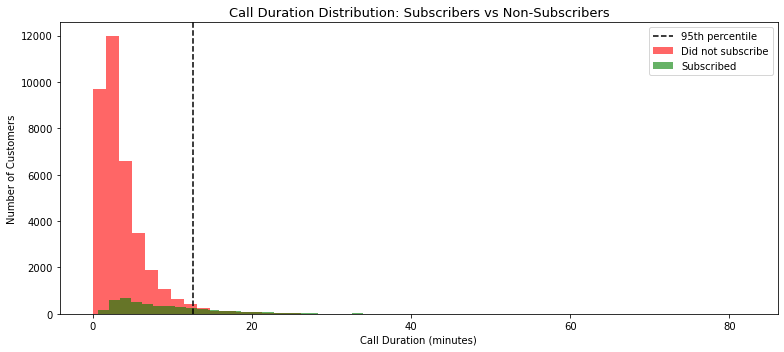

In [7]:
# ── Anomaly 2: Call duration outliers ────────────────────────────────────────
# Why: Very long calls that don't convert = agent inefficiency.
#      Very short calls that convert = something unusual happening.

df['duration_minutes'] = df['duration'] / 60

# Segment: long calls (top 5%) that did NOT convert
long_no_convert = df[
    (df['duration_minutes'] > df['duration_minutes'].quantile(0.95)) &
    (df['subscribed'] == 0)
]

print(f"\nLong calls (top 5%) with no conversion: {len(long_no_convert):,}")
print(f"Avg duration of these calls: {long_no_convert['duration_minutes'].mean():.1f} mins")
print(f"Wasted call time (hours): {long_no_convert['duration'].sum() / 3600:.0f} hours")

# Visualise duration distribution
plt.figure(figsize=(11, 5))
plt.hist(df[df['subscribed']==0]['duration_minutes'], bins=50,
         alpha=0.6, color='red', label='Did not subscribe')
plt.hist(df[df['subscribed']==1]['duration_minutes'], bins=50,
         alpha=0.6, color='green', label='Subscribed')
plt.axvline(df['duration_minutes'].quantile(0.95), color='black',
            linestyle='--', label='95th percentile')
plt.title('Call Duration Distribution: Subscribers vs Non-Subscribers', fontsize=13)
plt.xlabel('Call Duration (minutes)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/chart_08_duration_anomaly.png', dpi=150)
plt.show()


Underperforming segments (high volume, low conversion):
        job  total  converted  conversion_rate  wasted_contacts
blue-collar   9254        638             6.89             8616
   services   3969        323             8.14             3646


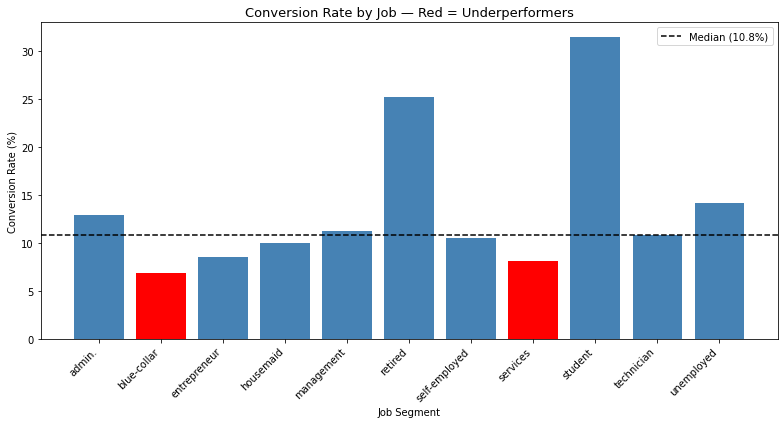


Underperformer report saved.


In [8]:
# ── Anomaly 3: Segments with high volume but very low conversion ─────────────
# Why: These are your underperforming segments — the "money pit" segments.
#      The CFO specifically wants to know: where are we spending effort for nothing?

segment_perf = df.groupby('job').agg(
    total=('subscribed', 'count'),
    converted=('subscribed', 'sum')
).reset_index()

segment_perf['conversion_rate'] = round(
    segment_perf['converted'] / segment_perf['total'] * 100, 2
)
segment_perf['wasted_contacts'] = segment_perf['total'] - segment_perf['converted']

# Flag segments: high volume (above median contacts) + low conversion (below median rate)
median_contacts = segment_perf['total'].median()
median_conversion = segment_perf['conversion_rate'].median()

underperformers = segment_perf[
    (segment_perf['total'] > median_contacts) &
    (segment_perf['conversion_rate'] < median_conversion)
].sort_values('wasted_contacts', ascending=False)

print("\nUnderperforming segments (high volume, low conversion):")
print(underperformers.to_string(index=False))

# Chart
plt.figure(figsize=(11, 6))
colors = ['red' if job in underperformers['job'].values else 'steelblue'
          for job in segment_perf['job']]
bars = plt.bar(segment_perf['job'], segment_perf['conversion_rate'], color=colors)
plt.axhline(y=median_conversion, color='black', linestyle='--',
            label=f'Median ({median_conversion:.1f}%)')
plt.title('Conversion Rate by Job — Red = Underperformers', fontsize=13)
plt.xlabel('Job Segment')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/chart_09_underperformers.png', dpi=150)
plt.show()

# Save anomaly report
underperformers.to_csv('outputs/underperforming_segments.csv', index=False)
print("\nUnderperformer report saved.")

In [10]:
# export_for_powerbi.py
# Purpose: Create clean, aggregated export files for Power BI dashboard
# Why: Power BI works best with pre-shaped data. This script is your data pipeline.

import pandas as pd

df = pd.read_csv('bank_customers_clean.csv')

bins = [0, 24, 34, 44, 54, 64, 100]
labels = ['Under 25', '25–34', '35–44', '45–54', '55–64', '65+']
df['age_band'] = pd.cut(df['age'], bins=bins, labels=labels)
df['duration_minutes'] = round(df['duration'] / 60, 2)

# Table 1: KPI summary (one-row summary card data)
kpi_summary = pd.DataFrame({
    'metric': ['Total Customers', 'Total Subscribed', 'Overall Conversion Rate (%)',
               'Avg Calls Per Customer', 'Max Calls to One Customer',
               'Avg Call Duration (mins)'],
    'value': [
        len(df),
        df['subscribed'].sum(),
        round(df['subscribed'].mean() * 100, 2),
        round(df['campaign'].mean(), 2),
        df['campaign'].max(),
        round(df['duration_minutes'].mean(), 2)
    ]
})

# Table 2: Job segment KPIs
job_table = df.groupby('job').agg(
    total_customers=('subscribed', 'count'),
    subscribed=('subscribed', 'sum'),
    avg_calls=('campaign', 'mean'),
    avg_duration_mins=('duration_minutes', 'mean')
).reset_index()
job_table['conversion_rate_pct'] = round(
    job_table['subscribed'] / job_table['total_customers'] * 100, 2
)
job_table['avg_calls'] = round(job_table['avg_calls'], 2)
job_table['avg_duration_mins'] = round(job_table['avg_duration_mins'], 2)

# Table 3: Monthly KPIs
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']
monthly_table = df.groupby('month').agg(
    contacts=('subscribed', 'count'),
    subscriptions=('subscribed', 'sum')
).reset_index()
monthly_table['success_rate_pct'] = round(
    monthly_table['subscriptions'] / monthly_table['contacts'] * 100, 2
)
monthly_table['month'] = pd.Categorical(
    monthly_table['month'], categories=month_order, ordered=True
)
monthly_table = monthly_table.sort_values('month').reset_index(drop=True)

# Table 4: Age band KPIs
age_table = df.groupby('age_band', observed=True).agg(
    total=('subscribed', 'count'),
    subscribed=('subscribed', 'sum')
).reset_index()
age_table['conversion_rate_pct'] = round(
    age_table['subscribed'] / age_table['total'] * 100, 2
)

# Table 5: Campaign efficiency
campaign_table = df.groupby('campaign').agg(
    contacts=('subscribed', 'count'),
    conversions=('subscribed', 'sum')
).reset_index()
campaign_table['conversion_rate_pct'] = round(
    campaign_table['conversions'] / campaign_table['contacts'] * 100, 2
)
campaign_table = campaign_table[campaign_table['campaign'] <= 15]

# Export all tables
kpi_summary.to_csv('outputs/pb_kpi_summary.csv', index=False)
job_table.to_csv('outputs/pb_job_segments.csv', index=False)
monthly_table.to_csv('outputs/pb_monthly.csv', index=False)
age_table.to_csv('outputs/pb_age_bands.csv', index=False)
campaign_table.to_csv('outputs/pb_campaign_efficiency.csv', index=False)
df.to_csv('outputs/pb_full_data.csv', index=False)

print("All Power BI export files saved:")
print("  pb_kpi_summary.csv")
print("  pb_job_segments.csv")
print("  pb_monthly.csv")
print("  pb_age_bands.csv")
print("  pb_campaign_efficiency.csv")
print("  pb_full_data.csv  ← main data table")

All Power BI export files saved:
  pb_kpi_summary.csv
  pb_job_segments.csv
  pb_monthly.csv
  pb_age_bands.csv
  pb_campaign_efficiency.csv
  pb_full_data.csv  ← main data table
